In [169]:
import os
import numpy as np
import h5py
from skimage.metrics import structural_similarity as ssim

Metrics

In [ ]:
## all test set
output_dir = 'DDPM/output/test/result_2d_epoch_1500'
categories = ['brain', 'pelvis', 'AB', 'HN', 'TH']
cat_mae = {cat: [] for cat in categories}
cat_ssim = {cat: [] for cat in categories}
all_mae = []
all_ssim = []

for i, file in enumerate(os.listdir(output_dir)):
    if file.endswith('.hdf5'):
        for cat in categories:
            if cat in file:
                with h5py.File(os.path.join(output_dir, file), 'r') as f:
                    pred = f['output'][()]
                    gt = f['target'][()]
                    input = f['input'][()]
                    mask = f['input_mask'][()]
                    gt = gt * mask
                    pred = pred * mask
                    mae = np.mean(np.abs(pred - gt))
                    ssim_value = ssim(pred, gt, data_range=1., channel_axis=None)
                    cat_mae[cat].append(mae)
                    cat_ssim[cat].append(ssim_value)
                    all_mae.append(mae)
                    all_ssim.append(ssim_value)
                break

for cat in categories:
    if cat_mae[cat]:
        print(cat)
        # print(f"MAE: {[round(x, 3) for x in cat_mae[cat]]}")
        # print(f"SSIM: {[round(x, 3) for x in cat_ssim[cat]]}")
        print(f"avg MAE = {np.mean(cat_mae[cat]):.5f}, avg SSIM = {np.mean(cat_ssim[cat]):.5f}, count = {len(cat_mae[cat])}")

print('avg MAE = ', np.mean(all_mae), 'avg SSIM = ', np.mean(all_ssim))


brain
avg MAE = 0.00820, avg SSIM = 0.93294, count = 65
pelvis
avg MAE = 0.00904, avg SSIM = 0.88869, count = 55
AB
avg MAE = 0.00909, avg SSIM = 0.87939, count = 47
HN
avg MAE = 0.00771, avg SSIM = 0.91221, count = 70
TH
avg MAE = 0.00867, avg SSIM = 0.88703, count = 76
avg MAE =  0.008484312 avg SSIM =  0.9013416483512752


Visualize

In [8]:
from matplotlib import pyplot as plt

def visualize_results(input, gt, pred, slice):
  """
  input, gt, pred: [d, w, h]
  """
  fig, axes = plt.subplots(1, 3, figsize=(15, 10))
  # vmin = (0+1000)/4096
  # vmax = (200+1000)/4096
  vmin = 0
  vmax = 1
  axes[0].imshow(input[slice], cmap='gray', vmin=0, vmax=1)
  axes[0].set_title('Input')
  axes[1].imshow(gt[slice], cmap='gray', vmin=vmin, vmax=vmax)
  axes[1].set_title('Target')
  axes[2].imshow(pred[slice], cmap='gray', vmin=vmin, vmax=vmax)
  axes[2].set_title('Prediction')

  for ax in axes: ax.axis('off')
  plt.tight_layout()
  plt.show()
  plt.close(fig)

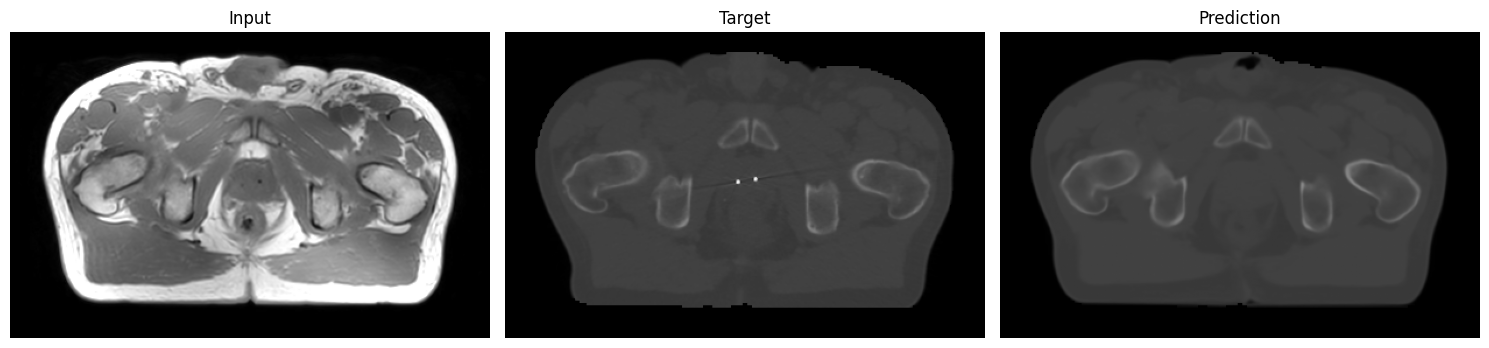

MAE: 0.011429519392549992, SSIM: 0.8529319995699195


In [9]:
output_dir = '/mnt/newdisk/diffusion/code_zjy/project/diffusion/DDPM/zjy/DDPM//output/test/' \
              'result_2d_epoch_1500'
file = 'synthrad2023_pelvis_1PA097.hdf5'
with h5py.File(os.path.join(output_dir, file), 'r') as f:
    pred = f['output'][()]
    gt = f['target'][()]
    input = f['input'][()]
    mask = f['input_mask'][()]
    gt = gt * mask
    pred = pred * mask
    visualize_results(input, gt, pred, slice=40)
    mae = np.mean(np.abs(pred - gt))
    ssim_value = ssim(pred, gt, data_range=1., channel_axis=None)
    print(f"MAE: {mae}, SSIM: {ssim_value}")